# M09 — Searchlight decoding: a center score describes a neighborhood

<!-- paper-first -->
### Research question

**Reading:** [PM02](../../curriculum/papers/modeling.md#pm02), [PD04](../../curriculum/papers/design.md#pd04). Review the assigned figure or result before starting the lesson.

**Question:** What does successful local decoding establish, and what would circular feature selection invalidate?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

**Original guided lab · 75–100 minutes.** Read 20 min, predict/code 35 min, failure investigation 20 min, explain and transfer 15 min. Run all cells in order in a fresh kernel. All executed data are synthetic unless explicitly stated. No network, GPU, or external dataset is required.

Searchlight analysis repeats an analysis over local neighborhoods of an image. A sphere around each center provides a set of voxel features; a classifier or another statistic is computed from those features; its result is placed at the center. The resulting map looks like a voxelwise measurement even though each number summarizes a neighborhood. Adjacent searchlights share many features and therefore yield strongly dependent scores.

Our one-dimensional strip substitutes for a three-dimensional voxel grid. A small region carries an invented class signal. At each center we fit logistic regression using its nearby columns and evaluate on held-out observations. The map identifies neighborhoods that contain informative columns. It does not show that the center voxel alone carries the information or that every voxel inside a successful neighborhood is necessary.

Neighborhood radius changes the hypothesis and feature count. A larger radius can capture distributed information but also include more nuisance features and increase overlap. In real images, specify the radius in physical units and use the image affine; a fixed number of voxel steps spans different physical distances for different resolutions. Searchlight masks near image boundaries can contain fewer voxels, which changes the effective problem across centers.

Every local model needs the same defensible validation design. For within-person fMRI, independent runs or temporal blocks may be needed; for between-person prediction, participants and related observations must remain separated. The synthetic observations here are independent, so a fixed row split is appropriate only for this generator. Learned preprocessing and feature selection must stay inside each training fold even though repeating them across centers is computationally expensive.

A high score at one of many searched centers is not automatically significant. Choosing the best center is another selection operation. Group inference and correction must account for the family of locations and the dependency structure, using a validated procedure suited to the design. The lab reports descriptive held-out scores and deliberately makes no map-level significance claim. You should be able to say exactly why a heat map is descriptive rather than an inferential result.

The failure exercise fits a flexible tree to random labels and reports training accuracy. It produces a perfect result from data with no constructed relationship. A successful training run therefore cannot validate a searchlight kernel. Ask AI to separate the code executed at each center, the split passed into that code, the map-writing operation, and the inference performed after the map exists. Those are separate responsibilities and each can fail silently.

## Transformation contract

Trials×positions `(200,41)` → overlapping local feature sets → fitted local classifiers → descriptive accuracy by center. Mapping compresses each neighborhood to one number and does not attribute that number uniquely to its center.

## Ask your AI tutor

```text
Explain this notebook one transformation at a time.
Before each cell ask me to predict shapes, units, and a check.
Give edits in executable cells of at most 20 lines.
Keep the prescribed split, random seed, and tests intact.
Distinguish generated suggestions from executed results.
After the failure experiment, ask me to explain the mechanism.
```

In [1]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
rng=np.random.default_rng(409)
y=np.tile([0,1],100);X=rng.normal(size=(200,41))
X[:,19:22]+=1.4*(2*y-1)[:,None]
tr,te=np.arange(120),np.arange(120,200)
scores=[]
for center in range(41):
    ix=np.arange(max(0,center-2),min(41,center+3))
    model=make_pipeline(StandardScaler(),LogisticRegression()).fit(X[tr][:,ix],y[tr])
    scores.append(model.score(X[te][:,ix],y[te]))
print('Signal-neighborhood score / distant average:',scores[20],np.mean(scores[:10]))
assert scores[20]>.9 and np.mean(scores[:10])<.65


Signal-neighborhood score / distant average: 0.9875 0.4912500000000001


Random-label train/test accuracy: 1.0 0.4875


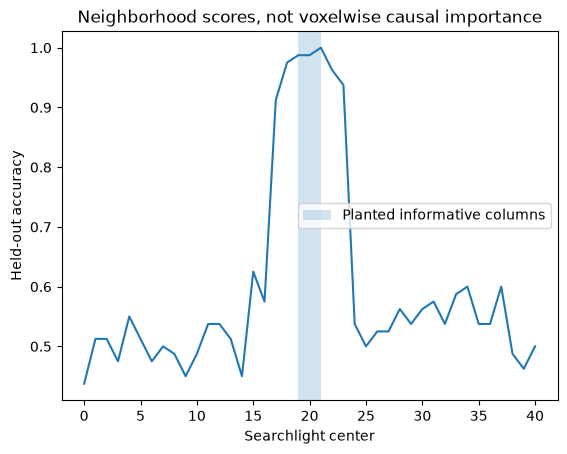

In [2]:
random_labels=rng.integers(0,2,200)
overfit=DecisionTreeClassifier(random_state=1).fit(X[tr],random_labels[tr])
print('Random-label train/test accuracy:',overfit.score(X[tr],random_labels[tr]),overfit.score(X[te],random_labels[te]))
assert overfit.score(X[tr],random_labels[tr])==1
assert overfit.score(X[te],random_labels[te])<.7
import matplotlib.pyplot as plt
plt.plot(scores);plt.axvspan(19,21,alpha=.2,label='Planted informative columns')
plt.xlabel('Searchlight center');plt.ylabel('Held-out accuracy')
plt.title('Neighborhood scores, not voxelwise causal importance');plt.legend();plt.show()


## Deliberate failure and repair

A random-label decision tree memorizes training examples. Reporting that score as searchlight performance creates an impressive false map. Repair by placing evaluation inside the local kernel and preserving independent groups. Do not select a center and estimate its effect again on the same outcomes without accounting for selection.

## Your investigation

Increase the radius from two to four columns and predict how the informative plateau changes. Explain why a center outside the planted interval can score highly. Design a real searchlight record including affine, mask, radius in mm, group split, classifier, scoring metric, and intended multiple-testing procedure.

## Transfer to real neuroimaging

The upstream tutorial uses real spatial data and the BrainIAK searchlight engine. It has additional data, infrastructure, and memory requirements. This lab executes the analysis pattern over a one-dimensional strip; it does not execute a NIfTI searchlight or group-level inference.

**Primary teaching sources, pinned where hosted on GitHub:**

- [BrainIAK: searchlight workflow](https://github.com/brainiak/brainiak-tutorials/blob/fb62ede943d9694fe703aee0df5f43ecf5558415/tutorials/07-searchlight.ipynb)
- [BrainIAK: double dipping](https://github.com/brainiak/brainiak-tutorials/blob/fb62ede943d9694fe703aee0df5f43ecf5558415/tutorials/05-classifier-optimization.ipynb)

Pinned upstream tutorials are a separate assignment; they have **not been executed** by this core lab. They may require data downloads, specialist dependencies, unfinished student cells, and additional compute.

## Exit questions and answer key

1. Does a successful center prove that voxel is informative alone? **No; its neighborhood supplied the features.**
2. Why are nearby scores dependent? **Searchlights share voxels and often share training/evaluation observations.**

### Return to the research question

Revisit [PM02](../../curriculum/papers/modeling.md#pm02), [PD04](../../curriculum/papers/design.md#pd04) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
